# Implementação de uma U-Net para Segmentação de Núcleos

Dataset: OralEpitheliumDB_Dataset (imagens de displasia — grupos `healthy` e `severe`).

Implementação de uma rede U-Net, utilizando os módulos básicos do PyTorch, para segmentação semântica de núcleos em imagens histológicas de epitélio oral.

* Experimento 1 — U-Net treinada sem aumento de dados;
* Experimento 2 — U-Net treinada com aumento de dados geométrico (rotação, espelhamentos horizontal/vertical, transposição).

## Configuração

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import glob
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Estilo dos gráficos
plt.rcParams['figure.figsize'] = (12, 5)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando device: {device}")

Mounted at /content/drive
Usando device: cuda


In [ ]:
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/Dados_Exploratorios/datasets")
IMAGES_DIR = BASE_DIR / "Original_ROI_images"
MASKS_DIR = BASE_DIR / "Gold_Standard_Semantic_Segmentation"

GROUPS = ["healthy", "severe"]

def list_images(group: str):
    folder = IMAGES_DIR / group
    return sorted([str(p) for p in folder.glob("*.tif")])

def get_mask_path(image_path: str, group: str):
    filename = os.path.basename(image_path)
    name_no_ext = os.path.splitext(filename)[0]
    return MASKS_DIR / group / f"{name_no_ext}.png"

image_paths = []
for group in GROUPS:
    paths = list_images(group)
    print(f"Grupo '{group}': {len(paths)} imagens encontradas")
    image_paths.extend([(p, group) for p in paths])

print(f"\nTotal de imagens (healthy + severe): {len(image_paths)}")

Grupo 'healthy': 114 imagens encontradas
Grupo 'severe': 114 imagens encontradas

Total de imagens (healthy + severe): 228


## Visualização


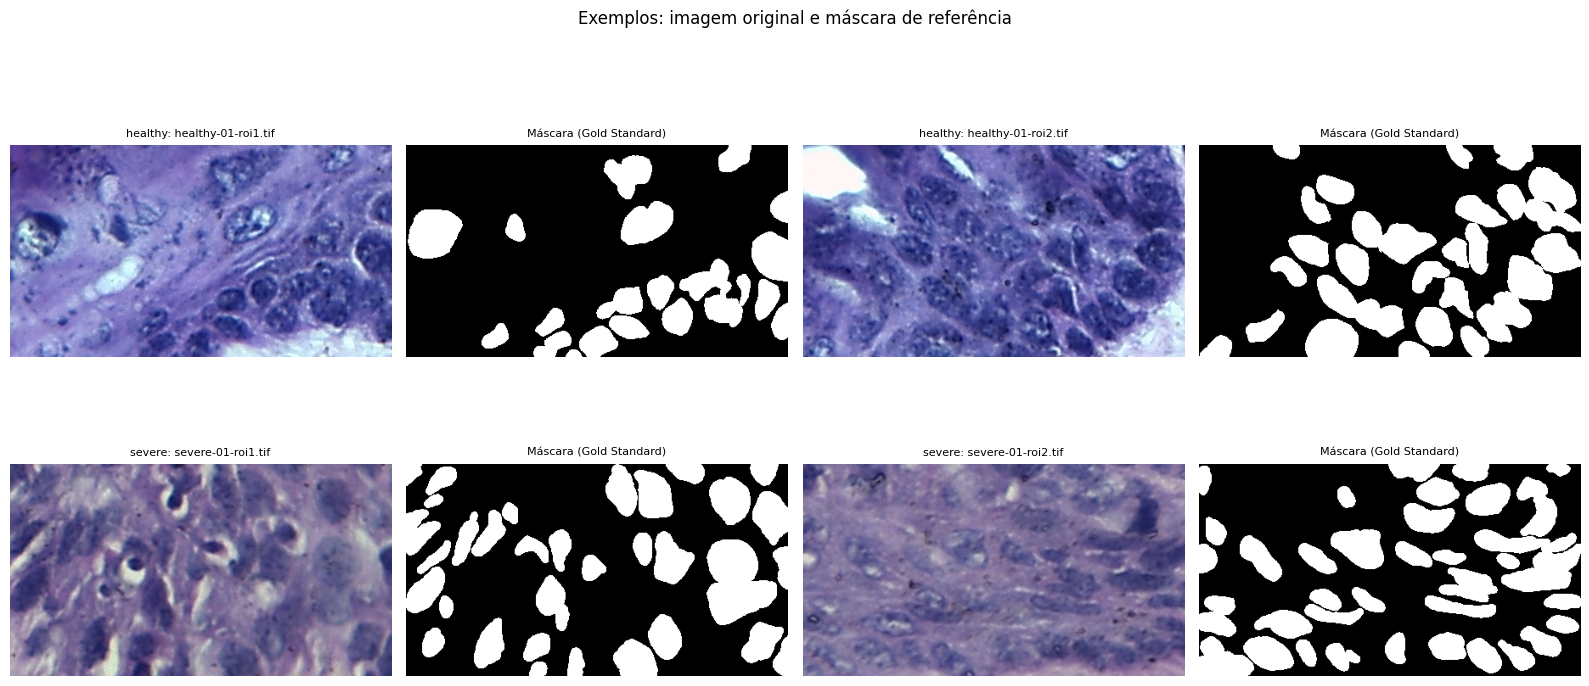

In [ ]:
def show_pair(image_path, group, ax_img, ax_mask):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(str(get_mask_path(image_path, group)), cv2.IMREAD_GRAYSCALE)

    ax_img.imshow(img_rgb)
    ax_img.set_title(f"{group}: {os.path.basename(image_path)}", fontsize=8)
    ax_img.axis("off")

    ax_mask.imshow(mask, cmap="gray")
    ax_mask.set_title("Máscara (Gold Standard)", fontsize=8)
    ax_mask.axis("off")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, group in enumerate(GROUPS):
    group_paths = [p for p, g in image_paths if g == group][:2]
    for j, p in enumerate(group_paths):
        show_pair(p, group, axes[i, j*2], axes[i, j*2 + 1])
fig.suptitle("Exemplos: imagem original e máscara de referência")
plt.tight_layout()
plt.show()

## Divisão em treino / validação / teste


In [ ]:
groups_all = [g for _, g in image_paths]

train_data, temp_data = train_test_split(
    image_paths, test_size=0.30, random_state=SEED, stratify=groups_all
)
temp_groups = [g for _, g in temp_data]
val_data, test_data = train_test_split(
    temp_data, test_size=0.50, random_state=SEED, stratify=temp_groups
)

print(f"Treino: {len(train_data)} imagens")
print(f"Validação: {len(val_data)} imagens")
print(f"Teste: {len(test_data)} imagens")

Treino: 159 imagens
Validação: 34 imagens
Teste: 35 imagens


## Dataset PyTorch


In [ ]:
IMG_SIZE = 256

class OralEpitheliumDataset(Dataset):
    """Dataset para segmentação binária (núcleo vs. fundo) do OralEpitheliumDB."""

    def __init__(self, data, img_size=IMG_SIZE, augment=False):
        self.data = data  # image_path, group
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.data)

    def _load_pair(self, image_path, group):
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(str(get_mask_path(image_path, group)), cv2.IMREAD_GRAYSCALE)

        img = cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)

        mask = (mask > 0).astype(np.uint8)  # 0 = fundo, 1 = núcleo
        return img, mask

    def _geometric_augment(self, img, mask):
        if random.random() < 0.5:  # espelhamento horizontal
            img = np.fliplr(img).copy()
            mask = np.fliplr(mask).copy()
        if random.random() < 0.5:  # espelhamento vertical
            img = np.flipud(img).copy()
            mask = np.flipud(mask).copy()
        if random.random() < 0.5:  # transposição
            img = np.transpose(img, (1, 0, 2)).copy()
            mask = np.transpose(mask, (1, 0)).copy()
        if random.random() < 0.5:  # rotação em múltiplos de 90 graus
            k = random.choice([1, 2, 3])
            img = np.rot90(img, k).copy()
            mask = np.rot90(mask, k).copy()
        return img, mask

    def __getitem__(self, idx):
        image_path, group = self.data[idx]
        img, mask = self._load_pair(image_path, group)

        if self.augment:
            img, mask = self._geometric_augment(img, mask)

        img = img.astype(np.float32) / 255.0
        img_tensor = torch.from_numpy(img.transpose(2, 0, 1)).float()
        mask_tensor = torch.from_numpy(mask).long()

        return img_tensor, mask_tensor

# Teste rápido
ds_demo = OralEpitheliumDataset(train_data[:1])
img_t, mask_t = ds_demo[0]
print(f"Imagem: {img_t.shape} | Máscara: {mask_t.shape} | Classes na máscara: {mask_t.unique().tolist()}")

Imagem: torch.Size([3, 256, 256]) | Máscara: torch.Size([256, 256]) | Classes na máscara: [0, 1]


## Arquitetura da U-Net

In [ ]:
class ConvBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=3,
        stride=1,
        padding=1,
        batchnorm=True,
        dropout_rate=0.0,
    ):
        super(ConvBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
            ),
            nn.BatchNorm2d(num_features=out_channels) if batchnorm else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=dropout_rate),
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
            ),
            nn.BatchNorm2d(num_features=out_channels) if batchnorm else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=dropout_rate),
        )

    def forward(self, x):
        return self.conv(x)


class Encoder(nn.Module):
    def __init__(self, in_channels, batchnorm, dropout_rate=0.0):
        super(Encoder, self).__init__()
        self.conv_blocks = nn.ModuleList(
            [
                ConvBlock(
                    in_channels=in_channels,
                    out_channels=64,
                    batchnorm=batchnorm,
                    dropout_rate=dropout_rate,
                ),
                ConvBlock(
                    in_channels=64,
                    out_channels=128,
                    batchnorm=batchnorm,
                    dropout_rate=dropout_rate,
                ),
                ConvBlock(
                    in_channels=128,
                    out_channels=256,
                    batchnorm=batchnorm,
                    dropout_rate=dropout_rate,
                ),
                ConvBlock(
                    in_channels=256,
                    out_channels=512,
                    batchnorm=batchnorm,
                    dropout_rate=dropout_rate,
                ),
            ]
        )
        self.max_pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        skip_connections = []
        for conv_block in self.conv_blocks:
            x = conv_block(x)
            skip_connections.append(x)
            x = self.max_pool(x)
        return x, skip_connections

In [ ]:
class Bottleneck(nn.Module):
    """Bloco central da U-Net: recebe a saída do encoder (512 canais) e gera a
    representação mais profunda da rede (1024 canais)."""

    def __init__(self, batchnorm, dropout_rate=0.0):
        super(Bottleneck, self).__init__()
        self.conv_block = ConvBlock(
            in_channels=512,
            out_channels=1024,
            batchnorm=batchnorm,
            dropout_rate=dropout_rate,
        )

    def forward(self, x):
        return self.conv_block(x)

In [ ]:
class UpConvBlock(nn.Module):
    """Bloco de upsampling do decoder: ConvTranspose2d, concatenação com a skip
    connection do encoder e um ConvBlock para refinar os mapas concatenados."""

    def __init__(self, in_channels, out_channels, batchnorm, dropout_rate=0.0):
        super(UpConvBlock, self).__init__()
        self.up = nn.ConvTranspose2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=2,
            stride=2,
        )
        # Após concatenar com a skip connection (que também tem out_channels
        # canais), o número de canais de entrada do ConvBlock dobra.
        self.conv_block = ConvBlock(
            in_channels=out_channels * 2,
            out_channels=out_channels,
            batchnorm=batchnorm,
            dropout_rate=dropout_rate,
        )

    def forward(self, x, skip_connection):
        x = self.up(x)
        x = torch.cat([x, skip_connection], dim=1)
        x = self.conv_block(x)
        return x

In [ ]:
class FinalConv(nn.Module):
    """Camada final: convolução 1x1 mapeando os canais finais do decoder para
    o número de classes da tarefa"""

    def __init__(self, in_channels, num_classes):
        super(FinalConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, num_classes, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

In [ ]:
class Decoder(nn.Module):
    """Caminho de expansão da U-Net: aplica upsampling, concatena com a skip
    connection correspondente e refina com convoluções, repetindo até
    recuperar a resolução espacial da entrada."""

    def __init__(self, batchnorm, dropout_rate=0.0, num_classes=2):
        super(Decoder, self).__init__()
        self.up_blocks = nn.ModuleList(
            [
                UpConvBlock(in_channels=1024, out_channels=512, batchnorm=batchnorm, dropout_rate=dropout_rate),
                UpConvBlock(in_channels=512, out_channels=256, batchnorm=batchnorm, dropout_rate=dropout_rate),
                UpConvBlock(in_channels=256, out_channels=128, batchnorm=batchnorm, dropout_rate=dropout_rate),
                UpConvBlock(in_channels=128, out_channels=64, batchnorm=batchnorm, dropout_rate=dropout_rate),
            ]
        )
        self.final_conv = FinalConv(in_channels=64, num_classes=num_classes)

    def forward(self, x, skip_connections):
        # As skip connections foram armazenadas na ordem do encoder
        # canais crescentes: 64, 128, 256, 512
        # no decoder usei a ordem inversa.
        skip_connections = skip_connections[::-1]

        for up_block, skip in zip(self.up_blocks, skip_connections):
            x = up_block(x, skip)

        return self.final_conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels, num_classes=2, dropout_rate=0.0, batchnorm=True):
        super(UNet, self).__init__()
        self.encoder = Encoder(in_channels, batchnorm, dropout_rate=dropout_rate)
        self.bottleneck = Bottleneck(batchnorm, dropout_rate=dropout_rate)
        self.decoder = Decoder(batchnorm, dropout_rate=dropout_rate, num_classes=num_classes)

    def forward(self, x):
        output, skip_connections = self.encoder(x)
        output = self.bottleneck(output)
        output = self.decoder(output, skip_connections)
        return output


# Teste rápido de forward, igual ao bloco de exemplo do enunciado,
# usando o mesmo IMG_SIZE e número de classes da nossa tarefa
NUM_CLASSES = 2  # 0: fundo, 1: núcleo

_model_demo = UNet(in_channels=3, num_classes=NUM_CLASSES, batchnorm=True)
_input_demo = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
_output_demo = _model_demo(_input_demo)
print("input shape:", _input_demo.shape)
print("output shape:", _output_demo.shape)
del _model_demo, _input_demo, _output_demo

input shape: torch.Size([1, 3, 256, 256])
output shape: torch.Size([1, 2, 256, 256])


## Configuração do modelo U-Net

treinada do zero.


In [ ]:
def build_unet_model(num_classes=NUM_CLASSES):
    model = UNet(in_channels=3, num_classes=num_classes, batchnorm=True, dropout_rate=0.0)
    return model.to(device)

## Métricas de avaliação

- DICE: mede a sobreposição entre a máscara prevista e a máscara real (classe núcleo).
- Acurácia de pixels: proporção de pixels classificados corretamente (todas as classes).
- IoU: razão entre interseção e união da máscara prevista com a real (classe núcleo).


In [ ]:
def pair_metrics(pred, true):
    """Calcula DICE, IoU e acurácia de pixels para um único par."""
    pred_fg = (pred == 1)
    true_fg = (true == 1)

    intersection = np.logical_and(pred_fg, true_fg).sum()
    union = np.logical_or(pred_fg, true_fg).sum()
    total = pred_fg.sum() + true_fg.sum()

    dice = 1.0 if total == 0 else (2.0 * intersection) / total
    iou = 1.0 if union == 0 else intersection / union
    pixel_acc = (pred == true).sum() / true.size

    return dice, iou, pixel_acc

## Aumento de dados e deformações elásticas

## Funções de treinamento e avaliação

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    return running_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_loss(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        running_loss += loss.item() * imgs.size(0)
    return running_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_metrics(model, loader, filenames):
    """Avalia o modelo em um DataLoader e retorna um DataFrame
    com DICE, IoU e acurácia de pixels calculados imagem a imagem."""
    model.eval()
    rows = []
    idx = 0
    for imgs, masks in loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        trues = masks.numpy()

        for b in range(imgs.size(0)):
            dice, iou, pixel_acc = pair_metrics(preds[b], trues[b])
            rows.append({
                "filename": filenames[idx],
                "dice": dice,
                "iou": iou,
                "pixel_acc": pixel_acc,
            })
            idx += 1

    return pd.DataFrame(rows)


def run_experiment(train_data, val_data, test_data, augment_train,
                    epochs=15, batch_size=8, lr=1e-4, exp_name="exp"):
    train_ds = OralEpitheliumDataset(train_data, augment=augment_train)
    val_ds = OralEpitheliumDataset(val_data, augment=False)
    test_ds = OralEpitheliumDataset(test_data, augment=False)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=2)

    model = build_unet_model(num_classes=NUM_CLASSES)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": []}
    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss = evaluate_loss(model, val_loader, criterion)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        print(f"[{exp_name}] Época {epoch:02d}/{epochs} — loss treino: {train_loss:.4f} | loss validação: {val_loss:.4f}")

    test_filenames = [os.path.basename(p) for p, g in test_data]
    df_metrics = evaluate_metrics(model, test_loader, test_filenames)

    config = {
        "Função de perda": "CrossEntropyLoss",
        "Otimizador": "Adam",
        "Taxa de aprendizado": lr,
        "Número de épocas": epochs,
        "Tamanho do batch": batch_size,
        "Aumento de dados": "Sim (geométrico)" if augment_train else "Não",
    }

    return model, history, df_metrics, config

## Experimento 1: U-Net sem aumento de dados

In [ ]:
model_exp1, history_exp1, df_metrics_exp1, config_exp1 = run_experiment(
    train_data, val_data, test_data,
    augment_train=False,
    epochs=15, batch_size=8, lr=1e-4,
    exp_name="Exp. 1 (sem aumento)"
)

pd.DataFrame([config_exp1])

[Exp. 1 (sem aumento)] Época 01/15 — loss treino: 0.5770 | loss validação: 0.5704
[Exp. 1 (sem aumento)] Época 02/15 — loss treino: 0.4585 | loss validação: 0.4372
[Exp. 1 (sem aumento)] Época 03/15 — loss treino: 0.4070 | loss validação: 0.3752
[Exp. 1 (sem aumento)] Época 04/15 — loss treino: 0.3695 | loss validação: 0.3361
[Exp. 1 (sem aumento)] Época 05/15 — loss treino: 0.3550 | loss validação: 0.3533
[Exp. 1 (sem aumento)] Época 06/15 — loss treino: 0.3357 | loss validação: 0.3263
[Exp. 1 (sem aumento)] Época 07/15 — loss treino: 0.3151 | loss validação: 0.3189
[Exp. 1 (sem aumento)] Época 08/15 — loss treino: 0.2990 | loss validação: 0.3244
[Exp. 1 (sem aumento)] Época 09/15 — loss treino: 0.2835 | loss validação: 0.3149
[Exp. 1 (sem aumento)] Época 10/15 — loss treino: 0.2600 | loss validação: 0.3356
[Exp. 1 (sem aumento)] Época 11/15 — loss treino: 0.2361 | loss validação: 0.3479
[Exp. 1 (sem aumento)] Época 12/15 — loss treino: 0.2228 | loss validação: 0.3176
[Exp. 1 (sem aum

,Função de perda,Otimizador,Taxa de aprendizado,Número de épocas,Tamanho do batch,Aumento de dados
0,CrossEntropyLoss,Adam,0.0001,15,8,Não


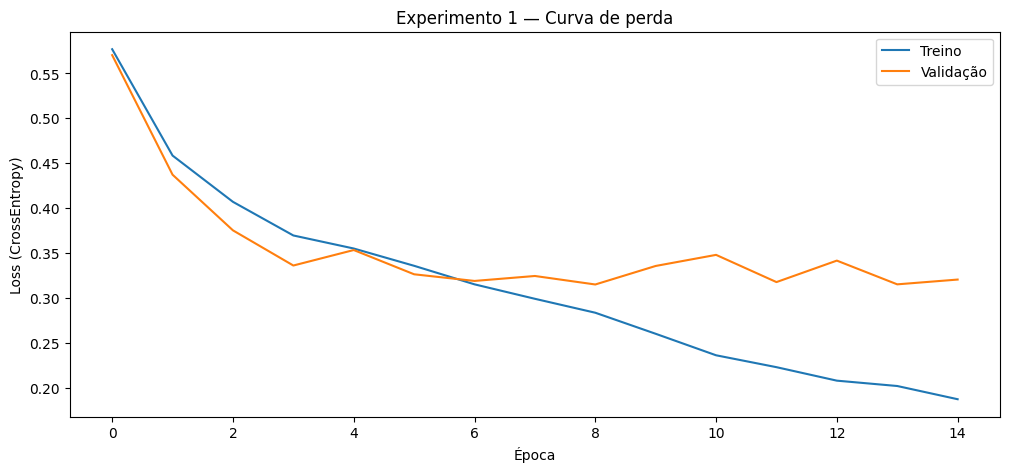

Métricas no conjunto de teste — Experimento 1:


,dice,iou,pixel_acc
mean,0.775085,0.638637,0.868528
std,0.076592,0.096998,0.046628


In [ ]:
plt.plot(history_exp1["train_loss"], label="Treino")
plt.plot(history_exp1["val_loss"], label="Validação")
plt.xlabel("Época"); plt.ylabel("Loss (CrossEntropy)")
plt.title("Experimento 1 — Curva de perda")
plt.legend()
plt.show()

print("Métricas no conjunto de teste — Experimento 1:")
df_metrics_exp1[["dice", "iou", "pixel_acc"]].agg(["mean", "std"])

## Experimento 2: U-Net com aumento de dados geométrico

Aplicando aumento de dados geométrico como espelhamentos, transposição e rotação em múltiplos de 90°

In [ ]:
model_exp2, history_exp2, df_metrics_exp2, config_exp2 = run_experiment(
    train_data, val_data, test_data,
    augment_train=True,
    epochs=15, batch_size=8, lr=1e-4,
    exp_name="Exp. 2 (com aumento geométrico)"
)

pd.DataFrame([config_exp2])

[Exp. 2 (com aumento geométrico)] Época 01/15 — loss treino: 0.5141 | loss validação: 0.5718
[Exp. 2 (com aumento geométrico)] Época 02/15 — loss treino: 0.4300 | loss validação: 0.4164
[Exp. 2 (com aumento geométrico)] Época 03/15 — loss treino: 0.4068 | loss validação: 0.4384
[Exp. 2 (com aumento geométrico)] Época 04/15 — loss treino: 0.3772 | loss validação: 0.3533
[Exp. 2 (com aumento geométrico)] Época 05/15 — loss treino: 0.3636 | loss validação: 0.3412
[Exp. 2 (com aumento geométrico)] Época 06/15 — loss treino: 0.3458 | loss validação: 0.3448
[Exp. 2 (com aumento geométrico)] Época 07/15 — loss treino: 0.3364 | loss validação: 0.3150
[Exp. 2 (com aumento geométrico)] Época 08/15 — loss treino: 0.3298 | loss validação: 0.3130
[Exp. 2 (com aumento geométrico)] Época 09/15 — loss treino: 0.3172 | loss validação: 0.3032
[Exp. 2 (com aumento geométrico)] Época 10/15 — loss treino: 0.3171 | loss validação: 0.2982
[Exp. 2 (com aumento geométrico)] Época 11/15 — loss treino: 0.3045 | 

,Função de perda,Otimizador,Taxa de aprendizado,Número de épocas,Tamanho do batch,Aumento de dados
0,CrossEntropyLoss,Adam,0.0001,15,8,Sim (geométrico)


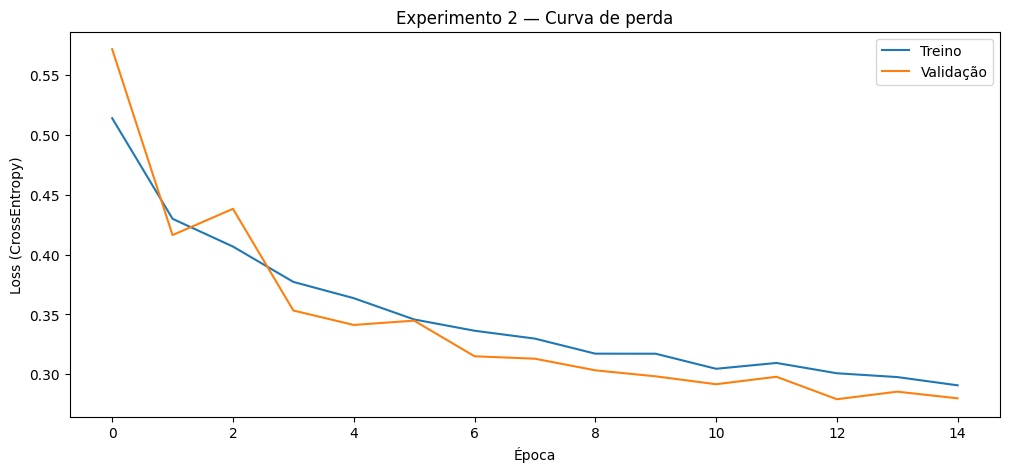

Métricas no conjunto de teste — Experimento 2:


,dice,iou,pixel_acc
mean,0.759549,0.617561,0.873491
std,0.073406,0.091666,0.046019


In [ ]:
plt.plot(history_exp2["train_loss"], label="Treino")
plt.plot(history_exp2["val_loss"], label="Validação")
plt.xlabel("Época"); plt.ylabel("Loss (CrossEntropy)")
plt.title("Experimento 2 — Curva de perda")
plt.legend()
plt.show()

print("Métricas no conjunto de teste — Experimento 2:")
df_metrics_exp2[["dice", "iou", "pixel_acc"]].agg(["mean", "std"])

## Comparação dos resultados

In [ ]:
def summarize(df_metrics, config, label):
    return {
        "Experimento": label,
        "Aumento de dados": config["Aumento de dados"],
        "DICE": df_metrics["dice"].mean(),
        "Acurácia de pixels": df_metrics["pixel_acc"].mean(),
        "IoU": df_metrics["iou"].mean(),
        "Observações": "",
    }

summary_rows = [
    summarize(df_metrics_exp1, config_exp1, "U-Net sem aumento de dados"),
    summarize(df_metrics_exp2, config_exp2, "U-Net com aumento geométrico"),
]
df_summary = pd.DataFrame(summary_rows)
df_summary

,Experimento,Aumento de dados,DICE,Acurácia de pixels,IoU,Observações
0,U-Net sem aumento de dados,Não,0.775085,0.868528,0.638637,
1,U-Net com aumento geométrico,Sim (geométrico),0.759549,0.873491,0.617561,


## Comparação com a FCN (S19.A2)

Tabela juntando os resultados desta atividade com os resultados obtidos na FCN.


In [ ]:
fcn_summary_rows = [
    {"Arquitetura": "FCN", "Aumento de dados": "Não", "DICE": 0.754880, "Acurácia de pixels": 0.863602, "IoU": 0.610519},
    {"Arquitetura": "FCN", "Aumento de dados": "Sim (geométrico)", "DICE": 0.758919, "Acurácia de pixels": 0.870813, "IoU": 0.616439},
]

unet_summary_rows = [
    {"Arquitetura": "U-Net", "Aumento de dados": row["Aumento de dados"], "DICE": row["DICE"],
     "Acurácia de pixels": row["Acurácia de pixels"], "IoU": row["IoU"]}
    for row in summary_rows
]

df_comparacao_arquiteturas = pd.DataFrame(fcn_summary_rows + unet_summary_rows)
df_comparacao_arquiteturas

,Arquitetura,Aumento de dados,DICE,Acurácia de pixels,IoU
0,FCN,Não,0.754880,0.863602,0.610519
1,FCN,Sim (geométrico),0.758919,0.870813,0.616439
2,U-Net,Não,0.775085,0.868528,0.638637
3,U-Net,Sim (geométrico),0.759549,0.873491,0.617561


## Exemplos visuais das segmentações

Melhor e pior caso por DICE de cada experimento, comparando imagem original, máscara real e máscara prevista.


--- Experimento 1 (sem aumento) ---


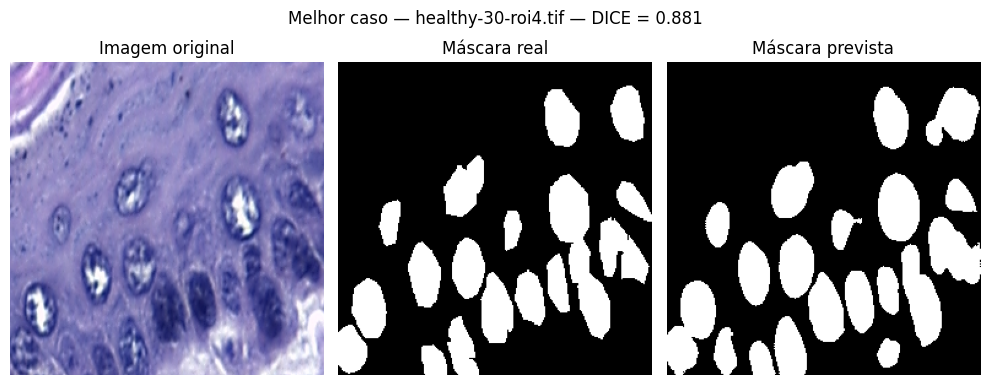

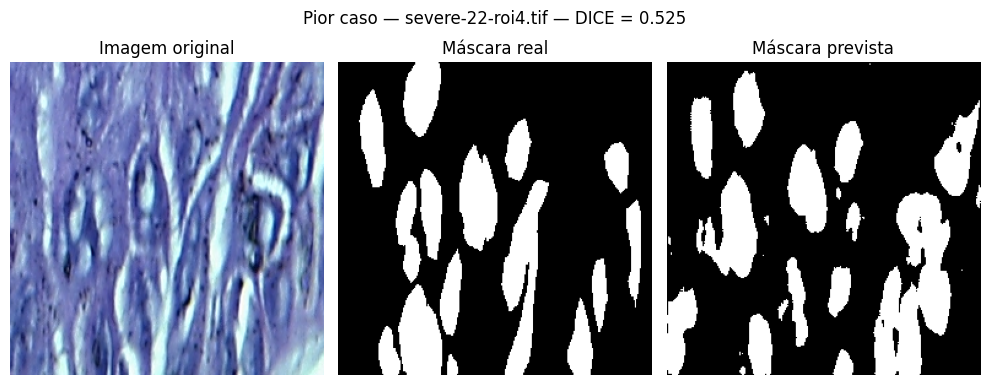

--- Experimento 2 (com aumento geométrico) ---


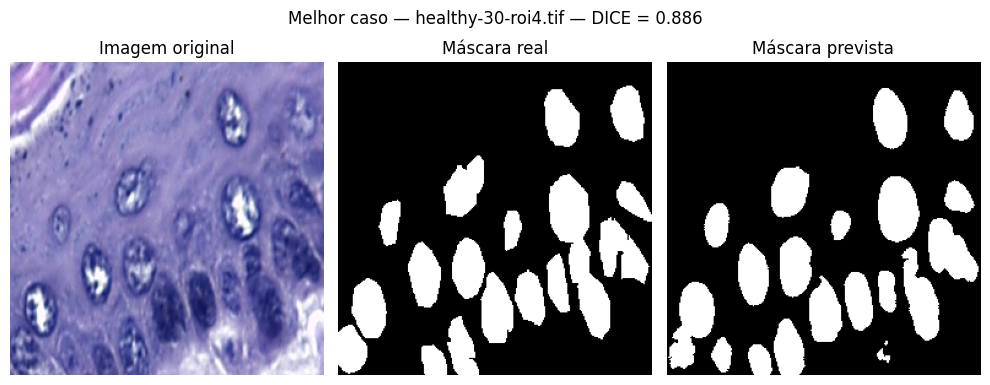

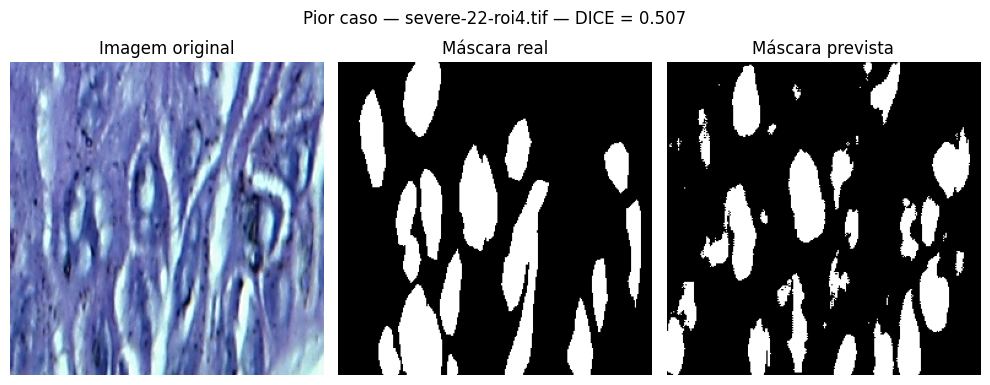

In [ ]:
@torch.no_grad()
def predict_mask(model, image_path, group, img_size=IMG_SIZE):
    ds = OralEpitheliumDataset([(image_path, group)], img_size=img_size, augment=False)
    img_tensor, mask_tensor = ds[0]
    model.eval()
    output = model(img_tensor.unsqueeze(0).to(device))
    pred = output.argmax(dim=1).squeeze(0).cpu().numpy()
    return pred, mask_tensor.numpy()


def show_prediction(model, df_metrics, test_data, pick="max", title=""):
    idx = df_metrics["dice"].idxmax() if pick == "max" else df_metrics["dice"].idxmin()
    filename = df_metrics.loc[idx, "filename"]
    image_path, group = next((p, g) for p, g in test_data if os.path.basename(p) == filename)

    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))

    pred, true_mask = predict_mask(model, image_path, group)

    fig, axes = plt.subplots(1, 3, figsize=(10, 4))
    axes[0].imshow(img_rgb); axes[0].set_title("Imagem original"); axes[0].axis("off")
    axes[1].imshow(true_mask, cmap="gray"); axes[1].set_title("Máscara real"); axes[1].axis("off")
    axes[2].imshow(pred, cmap="gray"); axes[2].set_title("Máscara prevista"); axes[2].axis("off")
    dice_val = df_metrics.loc[idx, "dice"]
    fig.suptitle(f"{title} — {filename} — DICE = {dice_val:.3f}")
    plt.tight_layout()
    plt.show()

print("--- Experimento 1 (sem aumento) ---")
show_prediction(model_exp1, df_metrics_exp1, test_data, pick="max", title="Melhor caso")
show_prediction(model_exp1, df_metrics_exp1, test_data, pick="min", title="Pior caso")

print("--- Experimento 2 (com aumento geométrico) ---")
show_prediction(model_exp2, df_metrics_exp2, test_data, pick="max", title="Melhor caso")
show_prediction(model_exp2, df_metrics_exp2, test_data, pick="min", title="Pior caso")

## Comparação conceitual entre FCN e U-Net

- **Backbone**: A FCN implementada na S19.A2 usa uma ResNet-50 pré-treinada no ImageNet como encoder, aproveitando características já aprendidas. A U-Net desta atividade é treinada inteiramente do zero, sem nenhum peso pré-treinado, aprendendo os padrões das imagens apenas com o dataset da atividade.

- **Skip connections**: Essa é a principal diferença, a FCN usa apenas a saída profunda do backbone, com upsampling até a resolução original, enquanto a U-Net concatena cada nível do encoder ao nível correspondente do decoder, recuperando detalhes espaciais que se perdem nas operações de pooling.

- **Simetria encoder/decoder**: a FCN não tem um decoder simétrico ao encoder. A U-Net tem um caminho de expansão espelhado ao de contração, com o mesmo número de níveis e canais em cada etapa correspondente.

- **Convoluções e resolução espacial**: A U-Net original usa convoluções sem padding, perdendo pixels de borda e exigindo recorte das skip connections antes da concatenação. A implementação desta atividade usa padding=1 em todas as convoluções, preservando a resolução espacial e dispensando o recorte.

- **Dependência de dados**:A U-Net precisaria de mais dados anotados para um bom desempenho por não ter pré-treinamento, mas nessa atividade, mesmo treinando do zero e sem aumento de dados, a U-Net (DICE 0,775) superou a FCN pré-treinada (DICE 0,755), sugerindo que o ganho das skip connections compensou a falta dos pesos iniciais.

- **Qualidade esperada da segmentação**: Era de se esperar que a U-Net preservasse melhor os contornos dos núcleos e separasse os agrupados, mas na análise da atividade S19.A2, a FCN sofreu com perda de núcleos pequenos e agrupados. A U-Net melhorou o DICE geral, mas os exemplos de pior caso mostram que ela também erra nessas regiões, apenas em menor grau do que a FCN.

## Análise dos resultados

1. A U-Net conseguiu segmentar corretamente os núcleos?

Sim, de forma geral. Nos dois experimentos o DICE ficou entre 0,76 e 0,78 e o IoU entre 0,62 e 0,64, indicando uma sobreposição boa entre a máscara prevista e a real. Nos exemplos de melhor caso, a máscara prevista fica bem próxima do Gold Standard, capturando a maioria dos núcleos. Nos exemplos de pior caso, o modelo erra em regiões específicas, mostrando que a segmentação média tem limitações.

2. O aumento de dados geométrico melhorou os resultados?

Nas métricas de teste, não. O DICE caiu de 0,775 sem aumento para 0,760 com aumento, e o IoU caiu de 0,639 para 0,618. A acurácia de pixels subiu um pouco, 0,869 para 0,873, mas conta pouco porque o fundo domina a imagem. Observando as curvas de loss, o aumento de dados ajudou o treinamento. Sem aumento, a loss de validação oscila e sobe depois da época 9, indicando overfitting. Com o aumento de dados, as perdas de treino e validação ficaram próximas, indicando melhor generalização, mesmo que isso não tenha se refletido diretamente nas métricas finais de segmentação.

3. Qual métrica apresentou maior diferença entre os experimentos?

O IoU foi a métrica que mais variou entre os dois experimentos da U-Net de 0,639 para 0,618. O DICE variou menos com 0,015 e a acurácia de pixels quase não mudou, ficou 0,004, o que era esperado, pois é a métrica menos sensível a erros na classe do núcleo.

4. A acurácia de pixels foi suficiente para avaliar corretamente a segmentação?

Não. O valor em torno de 0,87 nos dois experimentos é inflado pelo fundo, que ocupa a maior parte da imagem. Um modelo que não segmentasse nenhum núcleo ainda teria uma acurácia relativamente alta. Analisando o DICE e o IoU, que focam na classe de interesse, percebemos que a segmentação ainda tem erros relevantes.

5. Por que o IoU pode ser mais informativo do que a acurácia de pixels em imagens com grande quantidade de fundo?

O IoU é calculado apenas sobre a classe de interesse, comparando a interseção com a união das áreas prevista e real, sem contar os acertos no fundo. A acurácia de pixels mistura os acertos do fundo com os do núcleo, parecendo alta mesmo quando o modelo erra nos núcleos.

6. A U-Net apresentou mais dificuldade em núcleos pequenos, agrupados ou próximos das bordas?

Sim. Nos exemplos de pior caso, os erros aparecem concentrados onde os núcleos estão próximos ou são pequenos. Em vez de separar núcleos individuais, o modelo tende a fundir núcleos vizinhos em uma única região na máscara prevista, ou não detecta os menores. Núcleos isolados e médios são segmentados de forma mais fiel.

7. O modelo apresentou mais falsos positivos ou falsos negativos?

Mais falsos negativos. Nos exemplos de pior caso, a máscara prevista cobre uma área menor do que a real. O modelo deixa de marcar núcleos presentes em vez de prever onde não existem. Esse padrão também apareceu na FCN do experimento S19.A2. Como o fundo domina o treinamento, o modelo é mais conservador ao prever núcleos, especialmente em áreas de baixo contraste.

8. Como as skip connections influenciaram a qualidade da segmentação?

As skip connections provavelmente explicam por que a U-Net sem aumento superou a FCN sem aumento. Como a U-Net recupera, em cada nível do decoder, os detalhes espaciais capturados no encoder antes do pooling, ela consegue reconstruir contornos mais precisos.

9. Como os resultados obtidos se relacionam com as ideias apresentadas no artigo original da U-Net?

O artigo defende que combinar skip connections com deformações elásticas permite treinar a rede do zero com poucas imagens, que é o cenário do OralEpitheliumDB_Dataset. Mesmo sem aplicar deformações elásticas a U-Net treinada do zero já superou a FCN pré-treinada. O aumento de dados estabilizou o treinamento e reduziu o overfitting, mas sem melhorar as métricas finais. Isso sugere que, para ganhos reais de desempenho, seria necessário um aumento mais agressivo, como as deformações elásticas originais, e não apenas transformações geométricas.

10. Comparando com a FCN estudada anteriormente, quais diferenças você percebe na arquitetura e na qualidade esperada da segmentação?

As diferenças arquiteturais principais são o uso de backbone pré-treinado, a presença de skip connections e a simetria do decoder, os resultados mostram essas diferenças. Sem aumento de dados, a U-Net superou a FCN, reforçando a importância das skip connections mesmo sem pré-treinamento. Com o aumento de dados geométrico, as duas arquiteturas praticamente empataram e isso indica que o aumento ajudou a FCN a se aproximar, mas não destacou ainda mais a U-Net. A vantagem estrutural da U-Net fica mais evidente quando não há aumento de dados compensando as limitações da FCN.